In [44]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
import time
from tqdm import tqdm


sys.path.append("../")
from xThreat import xThreat

In [45]:
max_max_error = 0.014
max_max_error = 0.033

# Import the data

In [46]:
df_errors = pd.read_csv('../2-calculate-values/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M/sqrt(N)'] = df_errors['M']*df_errors['1/sqrt(N)']
df_errors['log(M)/sqrt(N)'] = np.log(df_errors['M'])*df_errors['1/sqrt(N)']

In [47]:
# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if ' 2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

In [48]:
df_errors.head()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,0.500000,0.022223,0.131414,1.0,1.0,192,0.0005,0.50472,0.096,0.002629
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,0.500000,0.008385,0.117864,1.0,1.0,192,0.0005,0.50472,0.096,0.002629
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,0.500000,0.006650,0.132075,1.0,1.0,192,0.0005,0.50472,0.096,0.002629
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,0.157143,0.011811,0.133729,1.0,1.0,192,0.0005,0.50472,0.096,0.002629
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,0.500000,0.012102,0.139206,1.0,1.0,192,0.0005,0.50472,0.096,0.002629


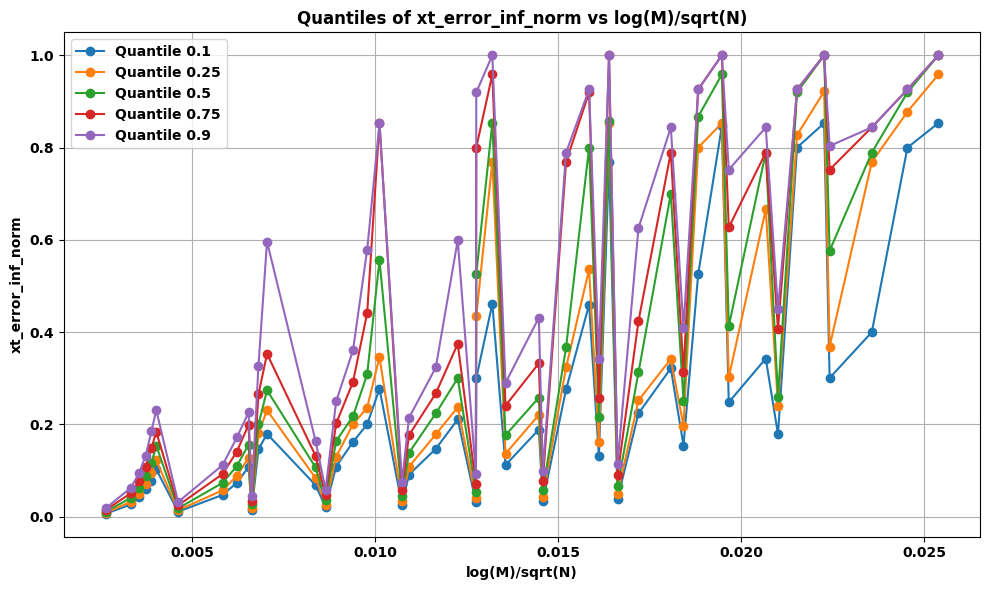

In [49]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('log(M)/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

plt.xlabel('log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xt_error_inf_norm vs log(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

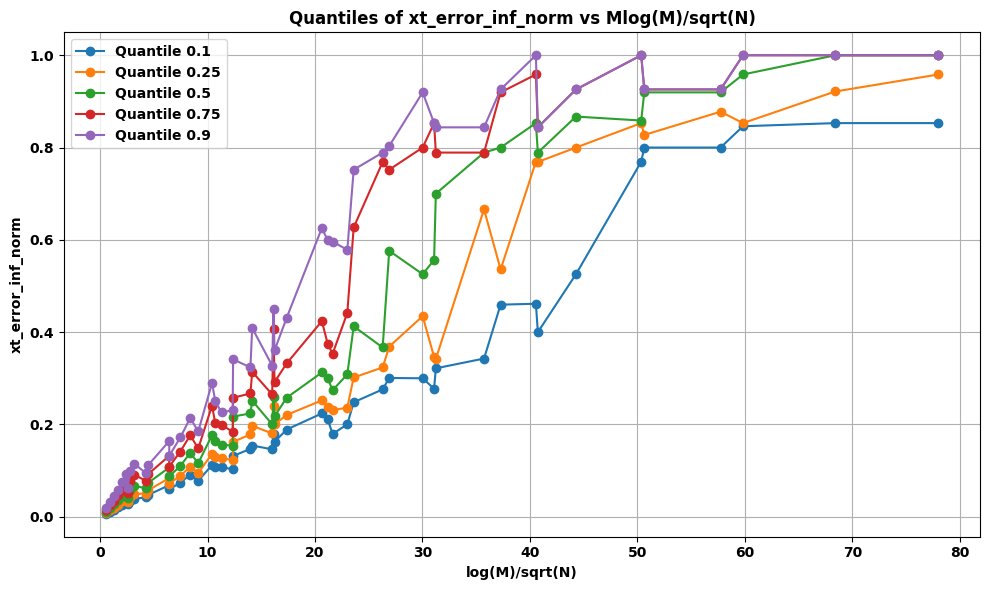

In [50]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('Mlog(M)/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

plt.xlabel('log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xt_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

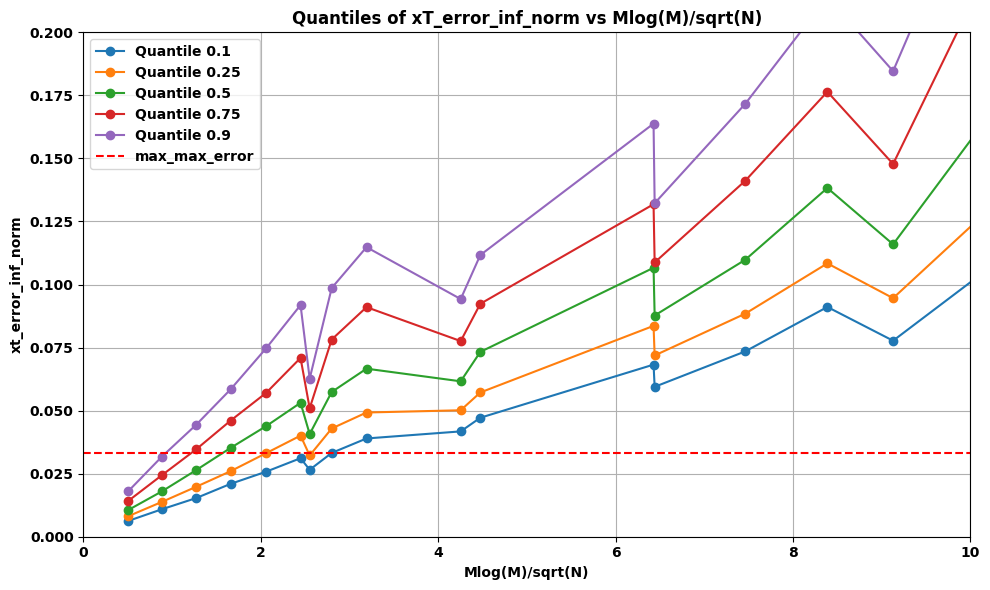

In [51]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('Mlog(M)/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Limit axes
plt.ylim(0.0, 0.2)
plt.xlim(0, 10)

plt.xlabel('Mlog(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

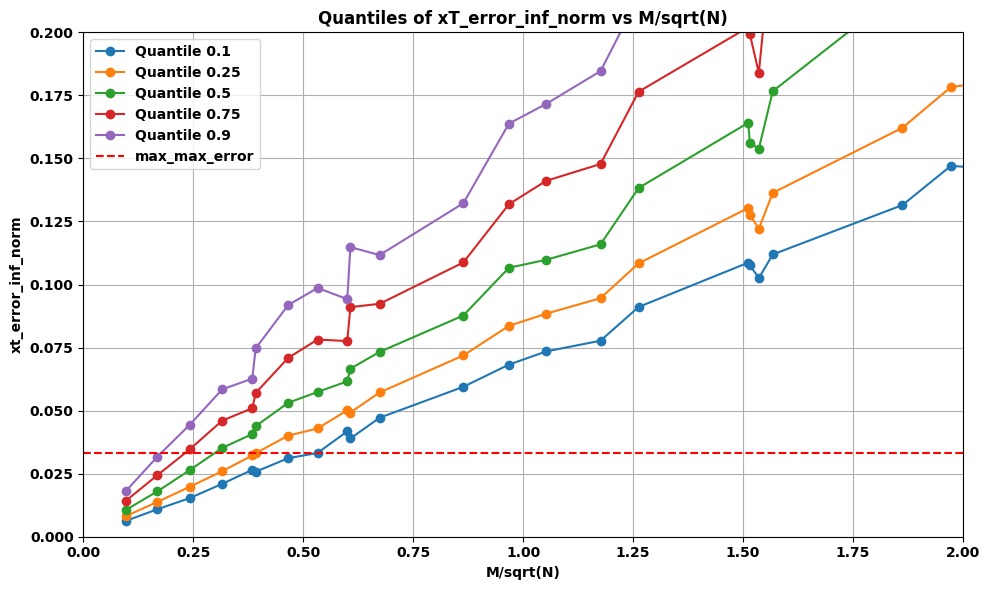

In [52]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('M/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Limit axes
plt.ylim(0.0, 0.2)
plt.xlim(0, 2)

plt.xlabel('M/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs M/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

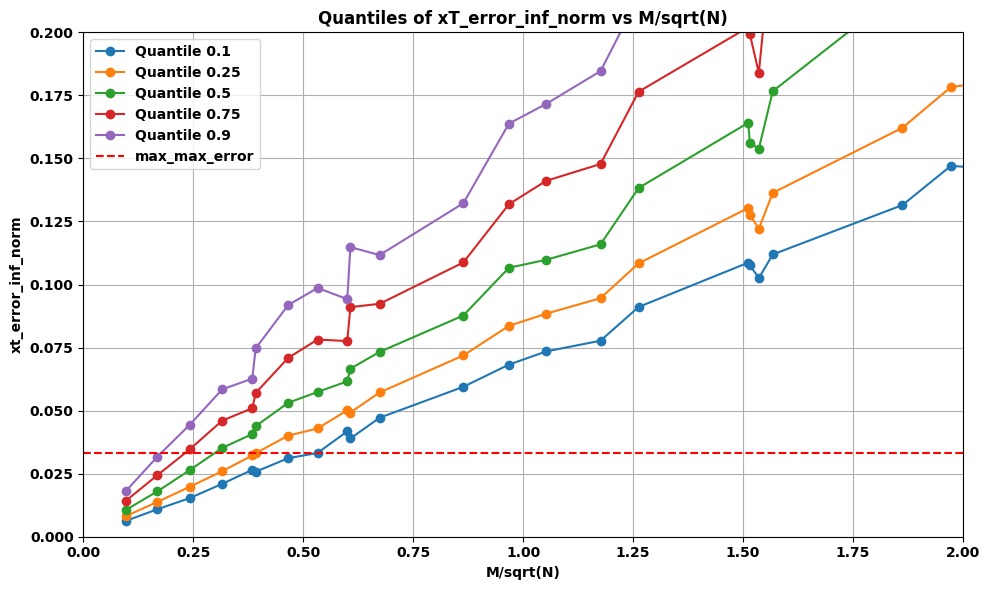

In [53]:
# Define the quantiles to compute
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

# Group by 'log(M)/sqrt(N)' and compute quantiles for 'xt_error_inf_norm'
grouped = df_errors.groupby('M/sqrt(N)')['xT_error_inf_norm']
quantile_df = grouped.quantile(quantiles).unstack()

# Plotting
plt.figure(figsize=(10, 6))
for q in quantiles:
    plt.plot(quantile_df.index, quantile_df[q], marker='o', label=f'Quantile {q}')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Limit axes
plt.ylim(0.0, 0.2)
plt.xlim(0, 2)

plt.xlabel('M/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs M/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
df_errors

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,0.500000,0.022223,0.131414,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,0.500000,0.008385,0.117864,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,0.500000,0.006650,0.132075,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,0.157143,0.011811,0.133729,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,0.500000,0.012102,0.139206,1.0,1.0,192,0.000500,0.504720,0.096000,0.002629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,64,48,100000,995,4805037,0.010060,0.007286,0.024008,0.013091,0.001156,...,1.000000,1.000000,1.928571,1.0,1.0,3072,0.003162,78.008388,9.714517,0.025393
47996,64,48,100000,996,4805038,0.008690,0.006119,0.023058,0.011962,0.001202,...,1.000000,1.000000,1.884615,1.0,1.0,3072,0.003162,78.008388,9.714517,0.025393
47997,64,48,100000,997,4805039,0.009090,0.006422,0.022428,0.012409,0.001110,...,1.000000,1.000000,1.865385,1.0,1.0,3072,0.003162,78.008388,9.714517,0.025393
47998,64,48,100000,998,4805040,0.010046,0.006882,0.023307,0.012695,0.001056,...,1.000000,1.000000,1.879518,1.0,1.0,3072,0.003162,78.008388,9.714517,0.025393


In [55]:
np.sum(df_errors['xT_error_inf_norm'] < max_max_error)

np.int64(3867)

In [56]:
per_Z_val = df_errors.groupby('Mlog(M)/sqrt(N)')['xT_error_inf_norm'].apply(lambda x: np.sum(x < max_max_error) / len(x))
per_Z_val = per_Z_val.reset_index()
per_Z_val.columns = ['Mlog(M)/sqrt(N)', 'percentage']
per_Z_val['percentage'] = per_Z_val['percentage'] * 100
per_Z_val['percentage'] = per_Z_val['percentage'].round(2)

per_Z_val

,Mlog(M)/sqrt(N),percentage
0,0.504720,100.0
1,0.885337,91.4
2,1.271774,70.6
3,1.659508,42.8
4,2.060509,24.8
5,2.448249,13.0
6,2.551215,27.5
7,2.799680,9.5
8,3.192127,4.4
9,4.254046,2.0


# OLS modeling

In [57]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

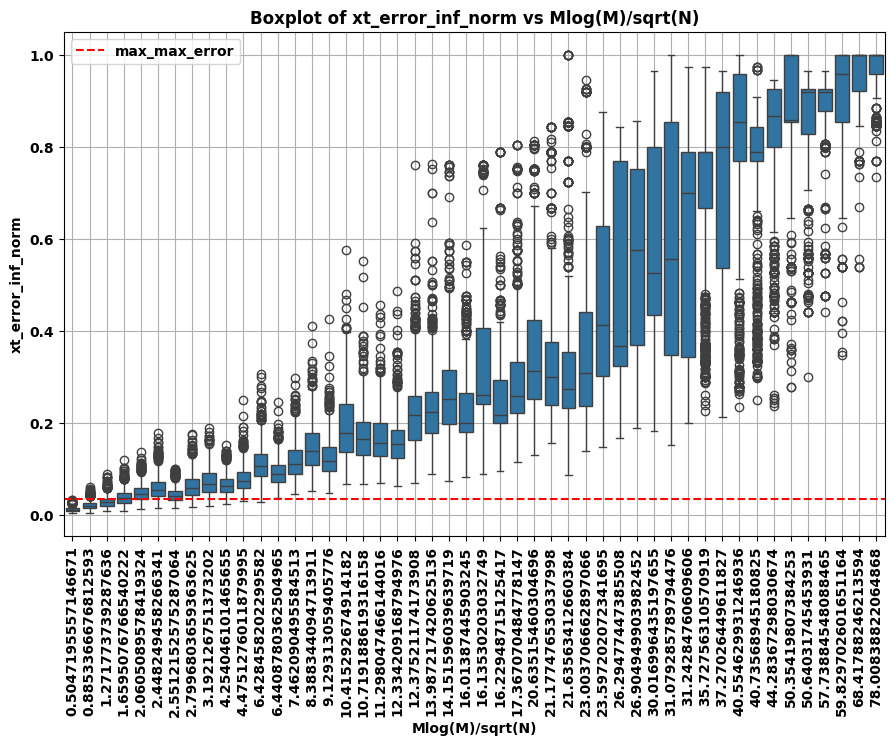

In [58]:
# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Mlog(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors)
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('Mlog(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

# current_values = plt.gca().get_xticks()
# plt.gca().set_xticklabels(['{:.2f}'.format(x) for x in current_values])

plt.show()

In [59]:
df_errors_ols = df_errors[df_errors['Mlog(M)/sqrt(N)'] < 15].copy()
df_errors_ols['sqrt(M)log(M)/sqrt(N)'] = df_errors_ols['log(M)/sqrt(N)'] * np.sqrt(df_errors_ols['M'])

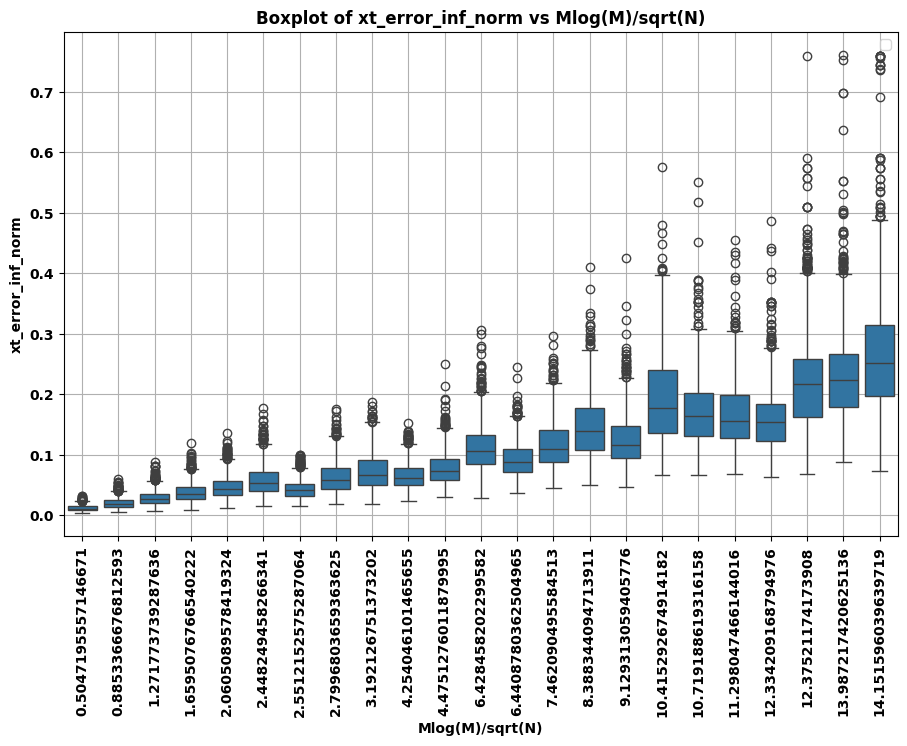

In [90]:
# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Mlog(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('Mlog(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

plt.show()

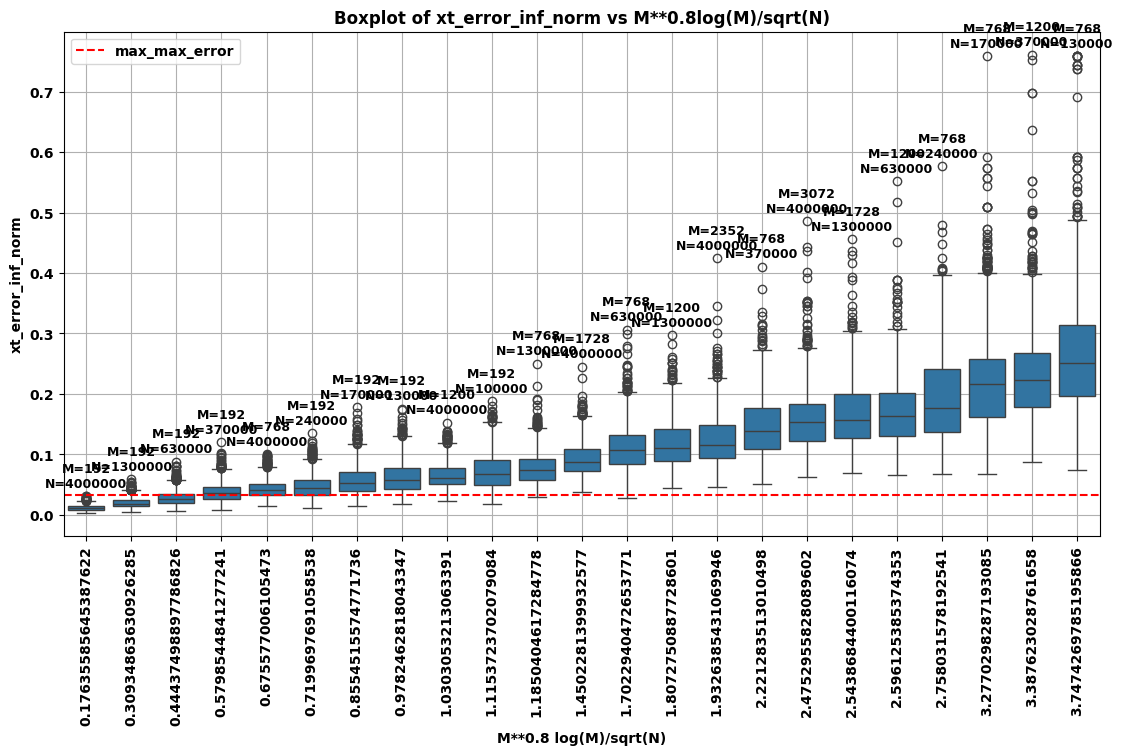

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

power = 0.8

df_errors_ols[f'M**{power} log(M)/sqrt(N)'] = df_errors_ols['M']**power * df_errors_ols['log(M)/sqrt(N)']

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x=f'M**{power} log(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)

# Add a red dashed line for max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Set labels and title
plt.xlabel(f'M**{power} log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title(f'Boxplot of xt_error_inf_norm vs M**{power}log(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)

# Annotate each box with M and N
grouped = df_errors_ols.groupby(f'M**{power} log(M)/sqrt(N)')
for i, (name, group) in enumerate(grouped):
    # Use the first row as a representative for M and N
    M = group['M'].iloc[0]
    N = group['N'].iloc[0]
    ax.text(i, group['xT_error_inf_norm'].max() + 0.01, f'M={M}\nN={N}',
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.show()


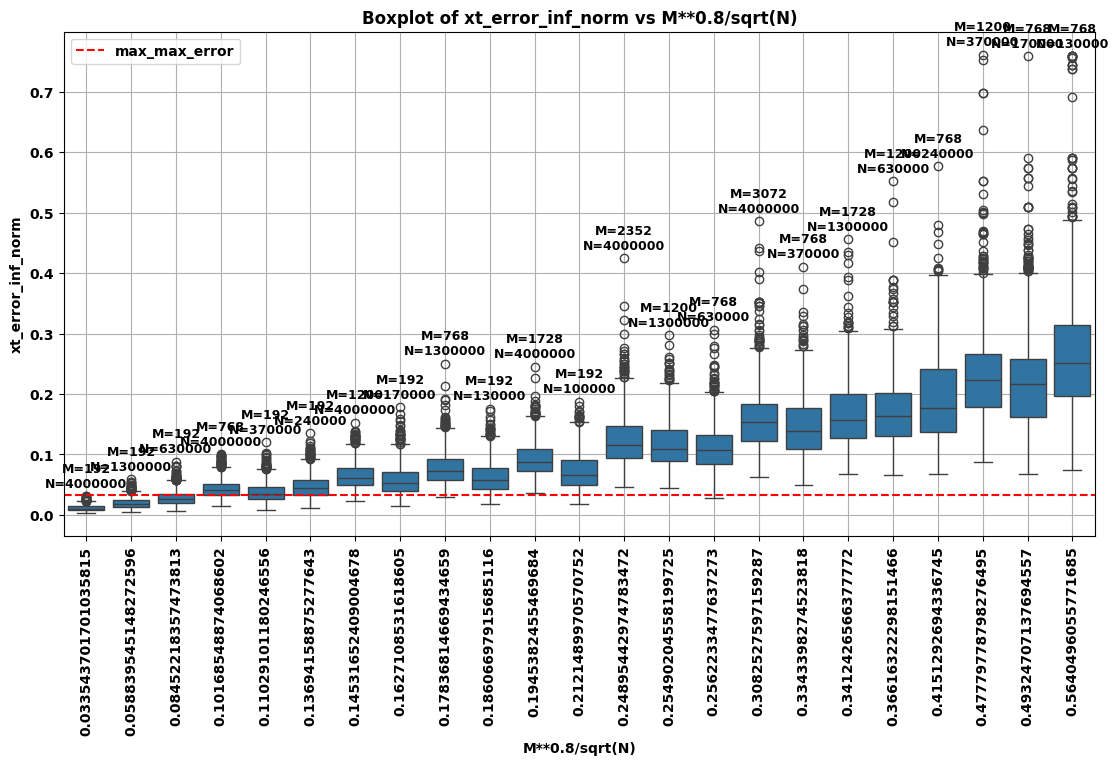

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

power = 0.8

df_errors_ols[f'M**{power}/sqrt(N)'] = df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x=f'M**{power}/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)

# Add a red dashed line for max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Set labels and title
plt.xlabel(f'M**{power}/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title(f'Boxplot of xt_error_inf_norm vs M**{power}/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)

# Annotate each box with M and N
grouped = df_errors_ols.groupby(f'M**{power}/sqrt(N)')
for i, (name, group) in enumerate(grouped):
    # Use the first row as a representative for M and N
    M = group['M'].iloc[0]
    N = group['N'].iloc[0]
    ax.text(i, group['xT_error_inf_norm'].max() + 0.01, f'M={M}\nN={N}',
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.show()


                            OLS Regression Results                            
Dep. Variable:      xT_error_inf_norm   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                 5.840e+04
Date:                 di, 22 apr 2025   Prob (F-statistic):               0.00
Time:                        12:31:36   Log-Likelihood:                -9281.8
No. Observations:               23000   AIC:                         1.857e+04
Df Residuals:                   22997   BIC:                         1.859e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -2.7567    

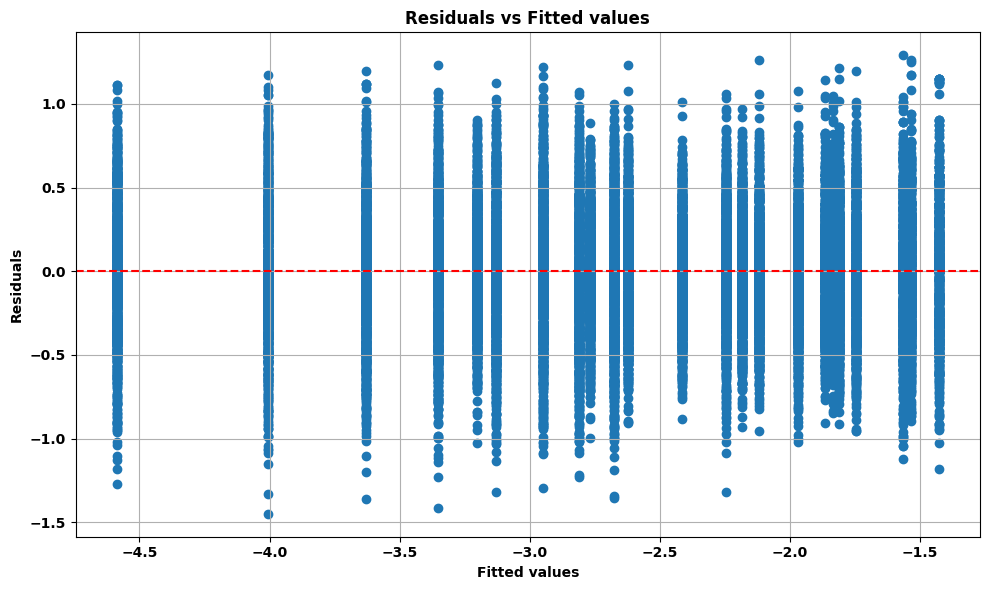

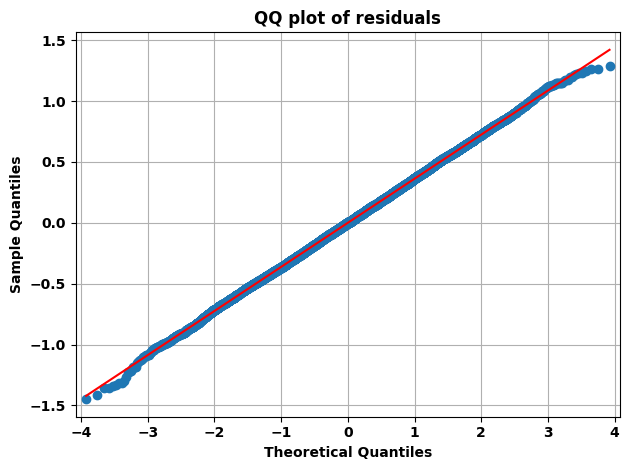

In [63]:
log_y = np.log(df_errors_ols['xT_error_inf_norm'])
log_x = np.log(df_errors_ols[f'log(M)/sqrt(N)'])
log_M = np.log(df_errors_ols['M'])

# Do OLS regression on log transformations

X = sm.add_constant(pd.DataFrame({'log(log(M)/sqrt(N))': log_x, 'log(M)': log_M}))
# X = sm.add_constant(np.array([log_x, log_M]).T)
Y = log_y
# Fit the model
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the QQ plot of the residuals
sm.qqplot(results.resid, line='s')
plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()


In [64]:
results.params

const                 -2.756723
log(log(M)/sqrt(N))    1.036484
log(M)                 0.823152
dtype: float64

In [65]:
c = results.params['const']
power = results.params['log(M)']
std_residuals = np.sqrt(results.mse_resid)
beta = results.params['log(log(M)/sqrt(N))']
print(f"c={c}")
print(f"power={power}")
print(f"std_residuals={std_residuals}")

c=-2.756723006298589
power=0.8231522326445235
std_residuals=0.36228818430864534


In [66]:
print(df_errors_ols['M'].unique().tolist())
print(df_errors_ols['N'].unique().tolist())

[192, 768, 1200, 1728, 2352, 3072]
[4000000, 1300000, 630000, 370000, 240000, 170000, 130000, 100000]


C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_13964\2394785489.py:6: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -power*np.log(M) - np.log(np.log(M)) + 0.5*np.log(N) + np.log(t), loc=0, scale=std_residuals)


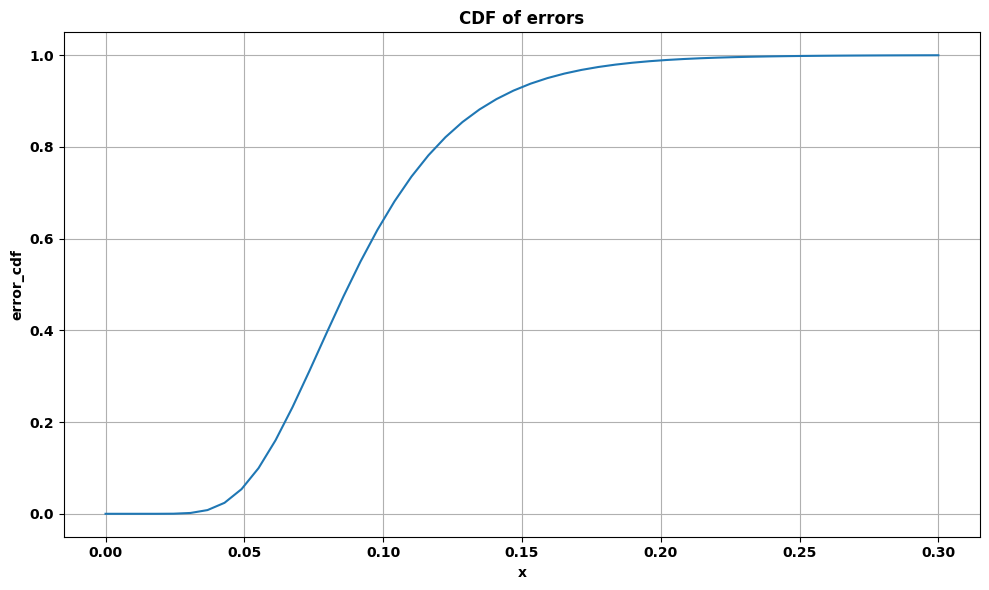

In [67]:
from scipy.stats import norm

M = 768
N = 1300000

error_cdf = lambda t: norm.cdf(-c -power*np.log(M) - np.log(np.log(M)) + 0.5*np.log(N) + np.log(t), loc=0, scale=std_residuals)

# Plot the function error_cdf
x = np.linspace(0, 0.30)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_13964\2481708627.py:1: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -power*np.log(M) - np.log(np.log(M)) + 0.5*np.log(N) + np.log(t), loc=0, scale=std_residuals)


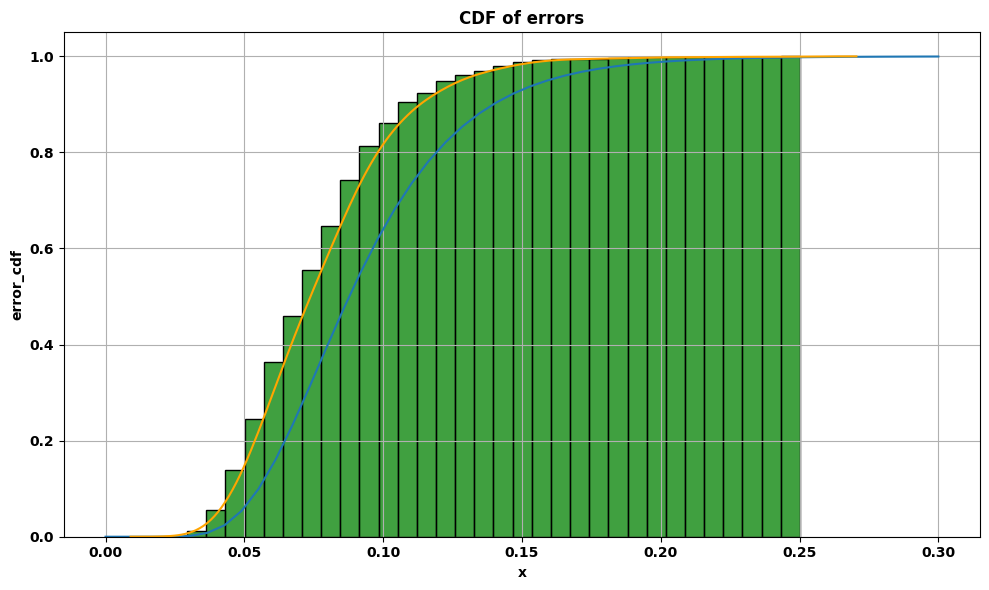

In [68]:
error_cdf = lambda t: norm.cdf(-c -power*np.log(M) - np.log(np.log(M)) + 0.5*np.log(N) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
# x = np.linspace(0, 0.10)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y)

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')


plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

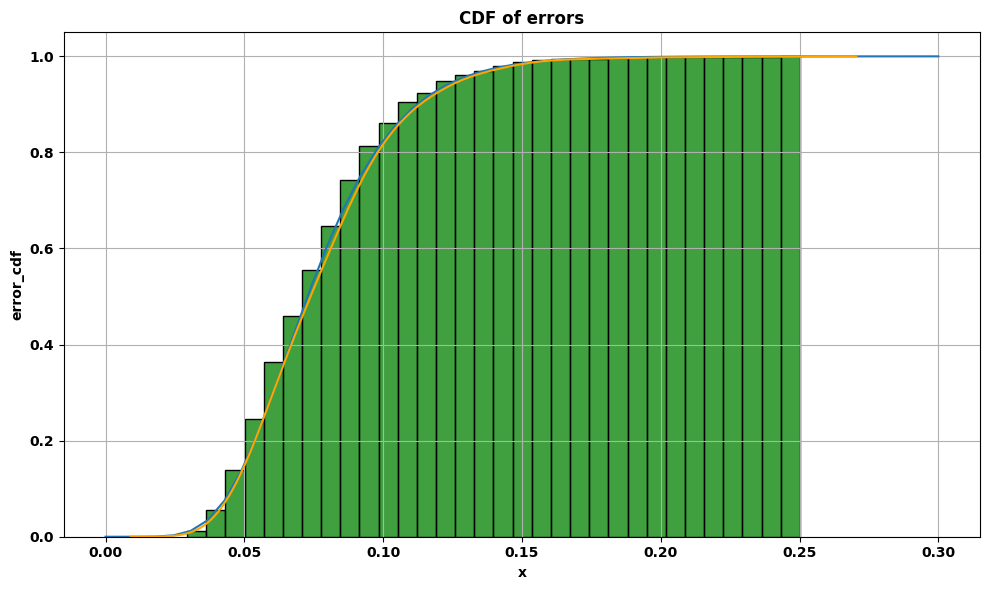

In [69]:
error_cdf = lambda t: norm.cdf(-c -power*np.log(M) - np.log(np.log(M)) + 0.5*np.log(N) + np.log(t+0.015), loc=0, scale=std_residuals*0.8)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
# x = np.linspace(0, 0.10)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y)

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')


plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

In [70]:
beta

np.float64(1.0364836888015085)

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_13964\2237280834.py:1: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta * np.log( np.sqrt(N)/np.log(M) ) + np.log(t), loc=0, scale=std_residuals)


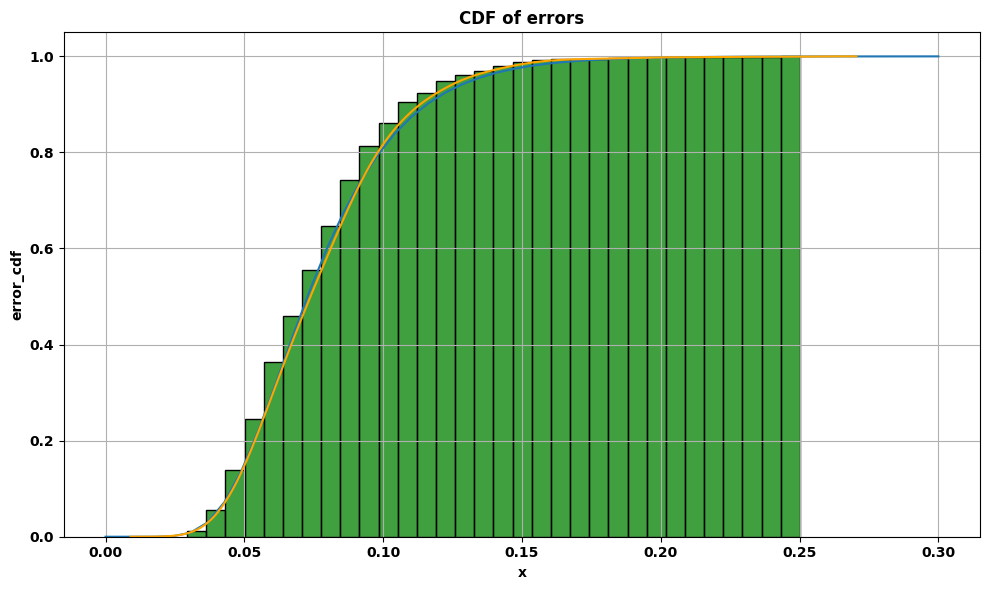

In [71]:
error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta * np.log( np.sqrt(N)/np.log(M) ) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
# x = np.linspace(0, 0.10)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y)

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')


plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

So heavy tailed for small log values (no problem).<br>
And light tailed for large log values (also favorable)/<br>

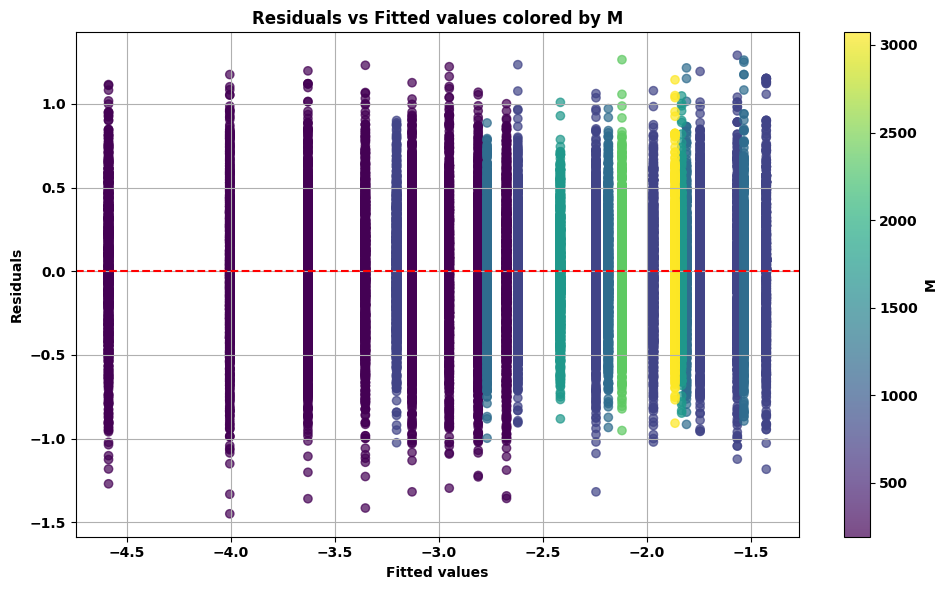

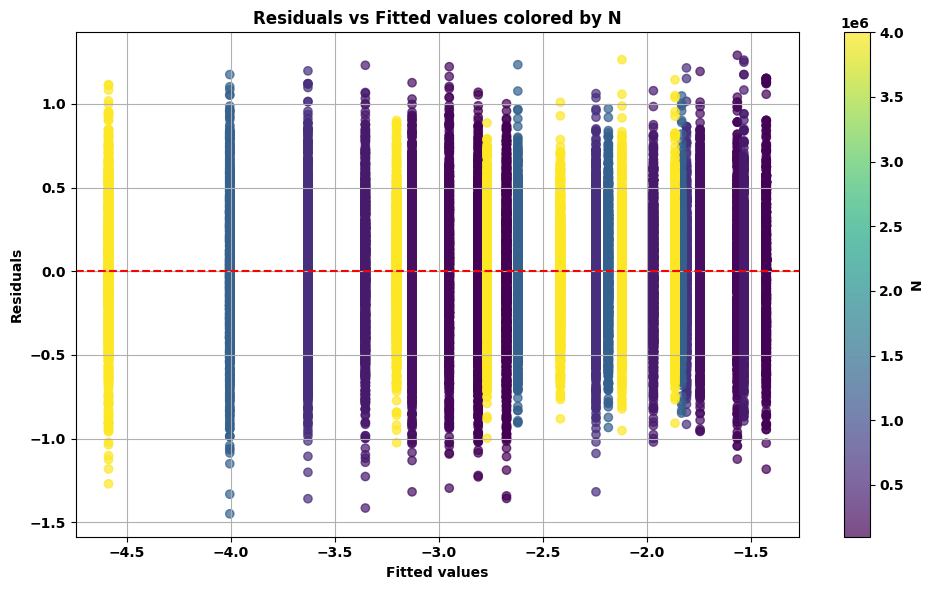

In [72]:
# Plot the residuals vs fitted values with colors for M
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, c=df_errors_ols['M'], cmap='viridis', alpha=0.7)
plt.colorbar(label='M')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
4
plt.title('Residuals vs Fitted values colored by M')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the residuals vs fitted values with colors for N
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, c=df_errors_ols['N'], cmap='viridis', alpha=0.7)
plt.colorbar(label='N')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values colored by N')
plt.grid(True)
plt.tight_layout()
plt.show()


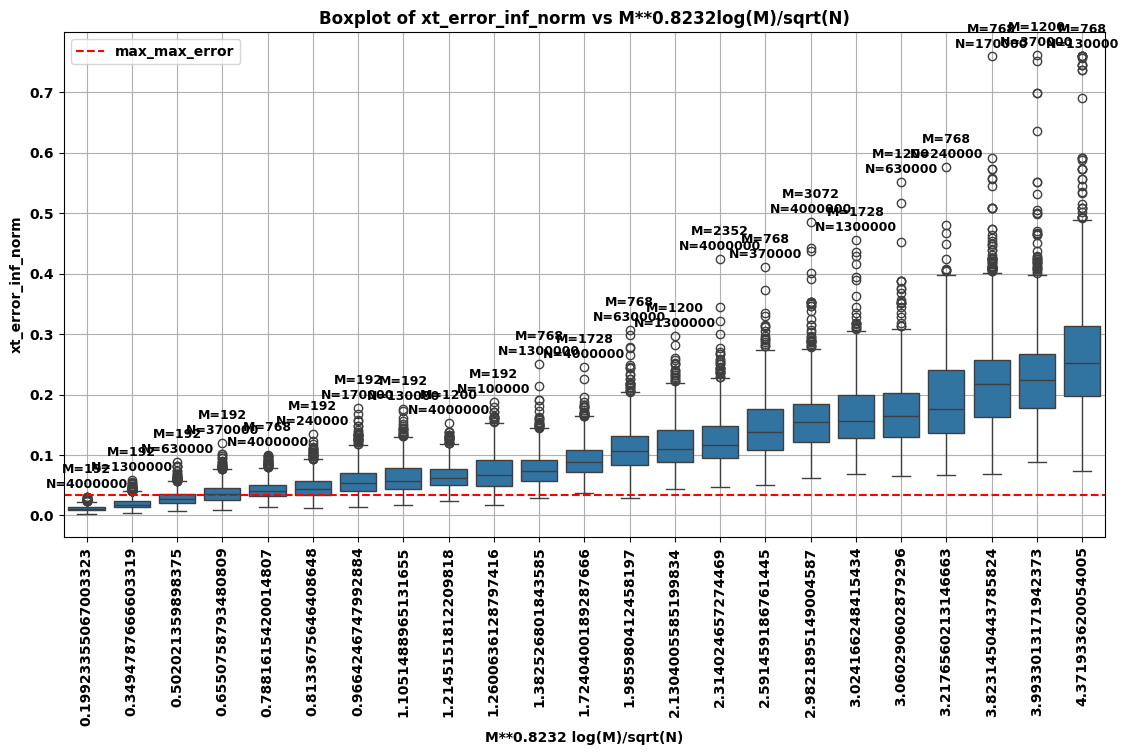

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

power = 0.8232

df_errors_ols[f'M**{power} log(M)/sqrt(N)'] = df_errors_ols['M']**power * df_errors_ols['log(M)/sqrt(N)']

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x=f'M**{power} log(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)

# Add a red dashed line for max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Set labels and title
plt.xlabel(f'M**{power} log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title(f'Boxplot of xt_error_inf_norm vs M**{power}log(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)

# Annotate each box with M and N
grouped = df_errors_ols.groupby(f'M**{power} log(M)/sqrt(N)')
for i, (name, group) in enumerate(grouped):
    # Use the first row as a representative for M and N
    M = group['M'].iloc[0]
    N = group['N'].iloc[0]
    ax.text(i, group['xT_error_inf_norm'].max() + 0.01, f'M={M}\nN={N}',
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.show()


In [74]:
max_max_error

0.033

## Seperate log(M) and sqrt(N) (or leave out log(M) at all as it doesn't seem to make such a difference...)

                            OLS Regression Results                            
Dep. Variable:      xT_error_inf_norm   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                 5.830e+04
Date:                 di, 22 apr 2025   Prob (F-statistic):               0.00
Time:                        12:31:38   Log-Likelihood:                -9297.8
No. Observations:               23000   AIC:                         1.860e+04
Df Residuals:                   22997   BIC:                         1.863e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.8758      0.026    -72.

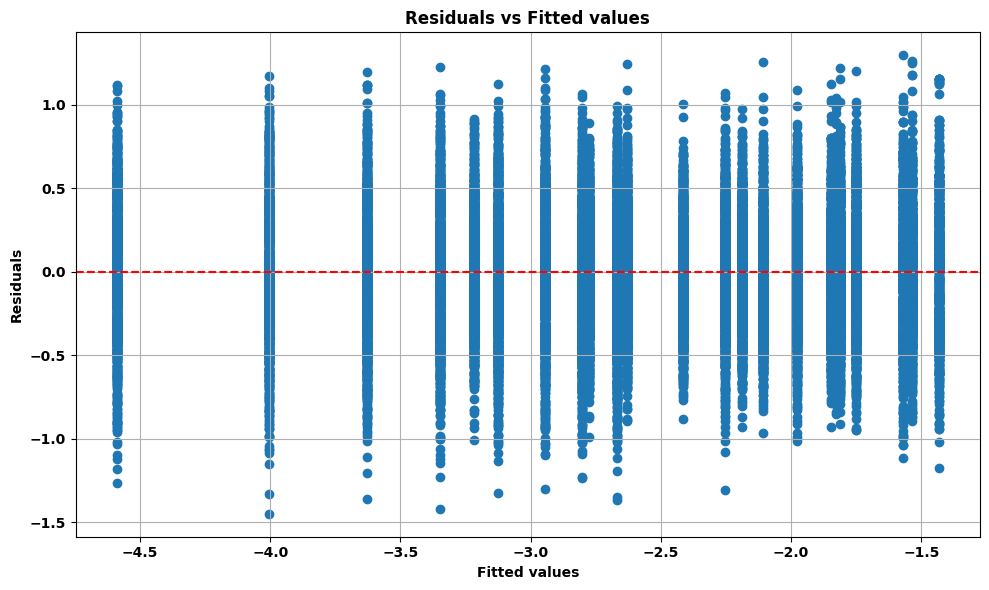

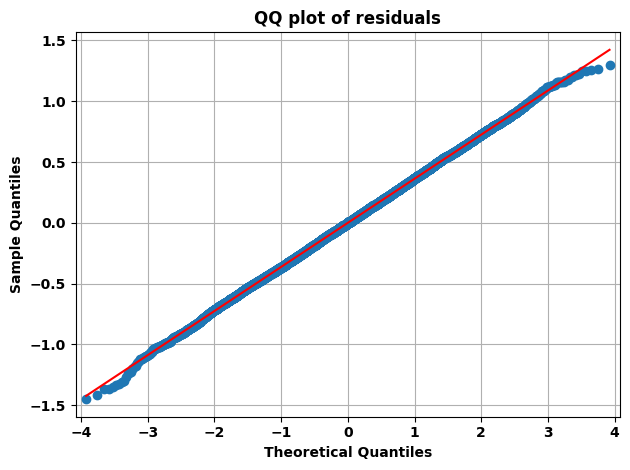

In [75]:
log_y = np.log(df_errors_ols['xT_error_inf_norm'])
log_x = np.log(df_errors_ols[f'log(M)/sqrt(N)'])
log_M = np.log(df_errors_ols['M'])

# Do OLS regression on log transformations

X = sm.add_constant(pd.DataFrame({
    # 'log(log(M))': np.log(np.log(df_errors_ols['M'])), 
    'log(M)': np.log(df_errors_ols['M']),
    'log(1/sqrt(N))': -np.log(np.sqrt(df_errors_ols['N']))
    }))
# X = sm.add_constant(np.array([log_x, log_M]).T)
Y = log_y
# Fit the model
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the QQ plot of the residuals
sm.qqplot(results.resid, line='s')
plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()


In [76]:
results.params

const            -1.875811
log(M)            0.989828
log(1/sqrt(N))    1.041632
dtype: float64

In [77]:
c = results.params['const']
power = results.params['log(M)']
std_residuals = np.sqrt(results.mse_resid)
beta = results.params['log(1/sqrt(N))']
print(f"c={c}")
print(f"power={power}")
print(f"std_residuals={std_residuals}")
print(f"beta={beta}")

c=-1.8758112050799398
power=0.9898277902846392
std_residuals=0.36253906130541547
beta=1.0416318444260435


In [78]:
1.0416318444260435*-0.5

-0.5208159222130218

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_13964\2234042866.py:6: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)


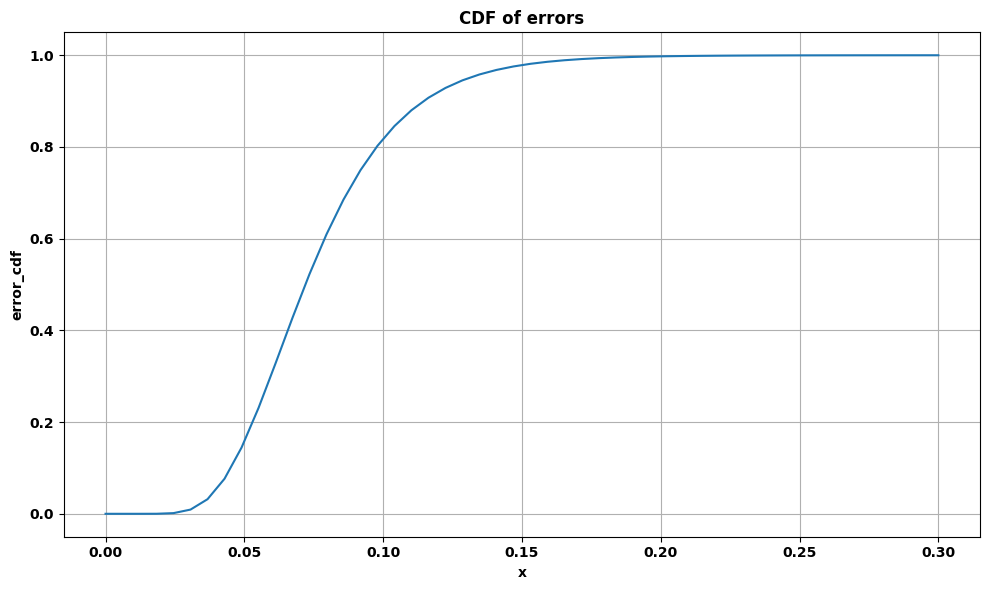

In [79]:
from scipy.stats import norm

M = 768
N = 1300000

error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

# Plot the function error_cdf
x = np.linspace(0, 0.30)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_13964\2847010552.py:1: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)


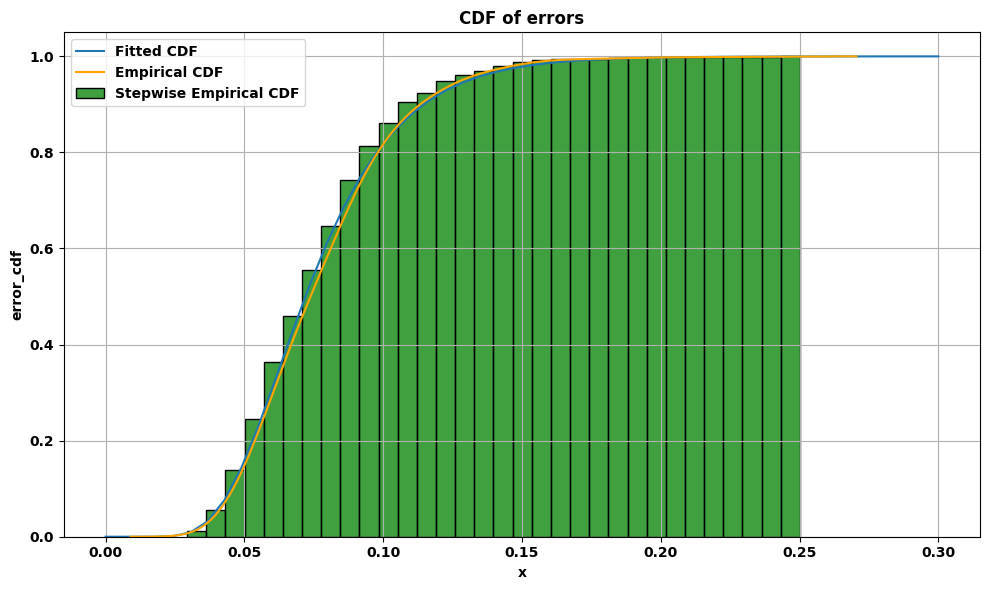

In [80]:
error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
# x = np.linspace(0, 0.10)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Fitted CDF')

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')

# Add legend
plt.legend()

plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
print(f"power={power}")
print(f"beta={beta}")
print(f"std_residuals={std_residuals}")
print(f"c={c}")

power=0.9898277902846392
beta=1.0416318444260435
std_residuals=0.36253906130541547
c=-1.8758112050799398


C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_13964\2270428202.py:1: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -1*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)


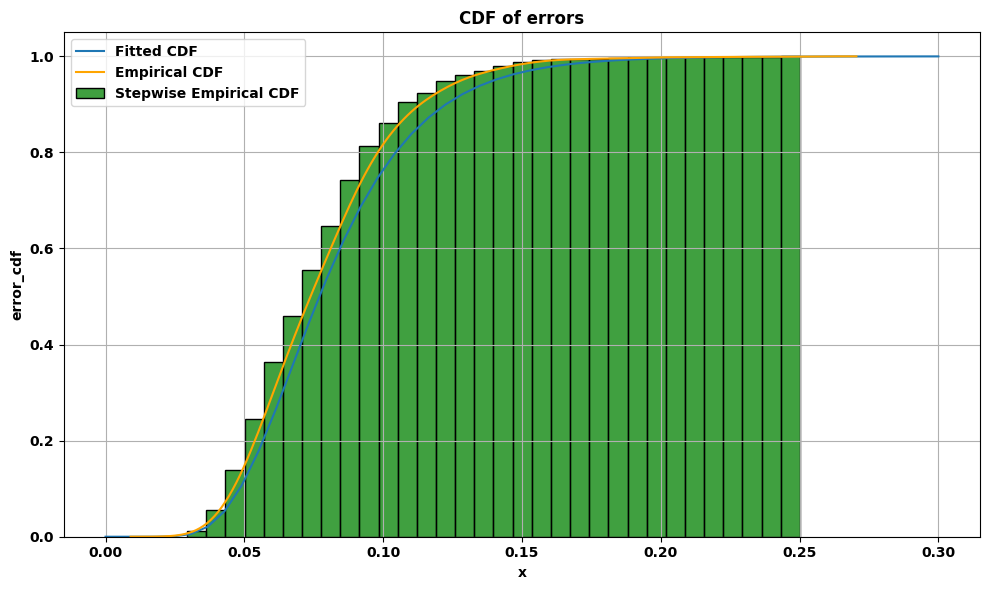

In [82]:
error_cdf = lambda t: norm.cdf(-c -1*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
# x = np.linspace(0, 0.10)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Fitted CDF')

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')

# Add legend
plt.legend()

plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_13964\777170421.py:1: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -1*np.log(M) + 1*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)


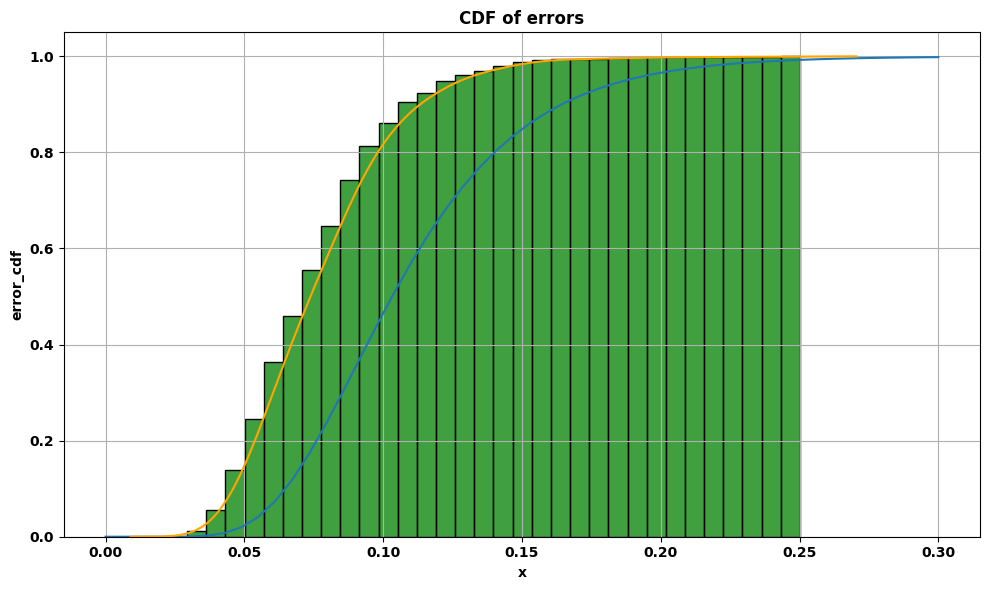

In [83]:
error_cdf = lambda t: norm.cdf(-c -1*np.log(M) + 1*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
# x = np.linspace(0, 0.10)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y)

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')

plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_13964\1218398574.py:4: RuntimeWarning: divide by zero encountered in log
  error_cdf = lambda t: norm.cdf(-c -0.9898277902846392*np.log(M) + 1.0416318444260435*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)


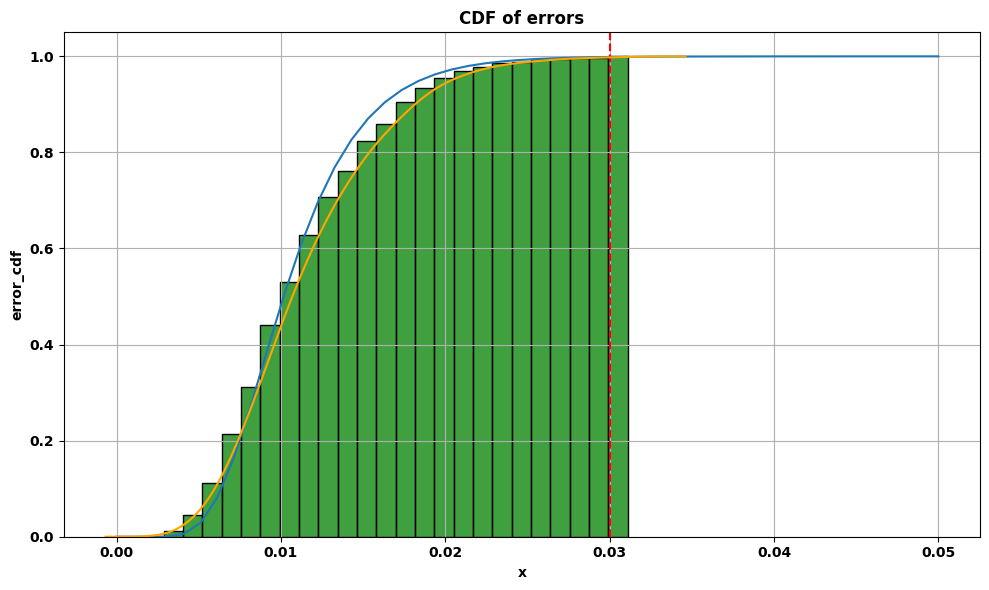

In [84]:
N = 4_000_000
M = 16*12

error_cdf = lambda t: norm.cdf(-c -0.9898277902846392*np.log(M) + 1.0416318444260435*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

data = df_errors_ols[(df_errors_ols['M'] == M) & (df_errors_ols['N'] == N)]['xT_error_inf_norm'].values

# Plot the function error_cdf
x = np.linspace(0, 0.050)
y = error_cdf(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y)
# vertical line at 0.03
plt.axvline(x=0.03, color='red', linestyle='--', label='max_max_error')

# Plot the emperical CDF
sns.kdeplot(data, cumulative=True, label='Empirical CDF', color='orange')

# Plot the stepwise emperical CDF
sns.histplot(data, cumulative=True, stat='density', bins='auto', kde=False, label='Stepwise Empirical CDF', color='green')

plt.xlabel('x')
plt.ylabel('error_cdf')
plt.title('CDF of errors')
plt.grid(True)
plt.tight_layout()
plt.show()

## Investigate if log(M) should be kept in there

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                 1.043e+05
Date:                 di, 22 apr 2025   Prob (F-statistic):               0.00
Time:                        12:31:39   Log-Likelihood:                 31178.
No. Observations:               23000   AIC:                        -6.235e+04
Df Residuals:                   22997   BIC:                        -6.233e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.7078      0.004   -158.

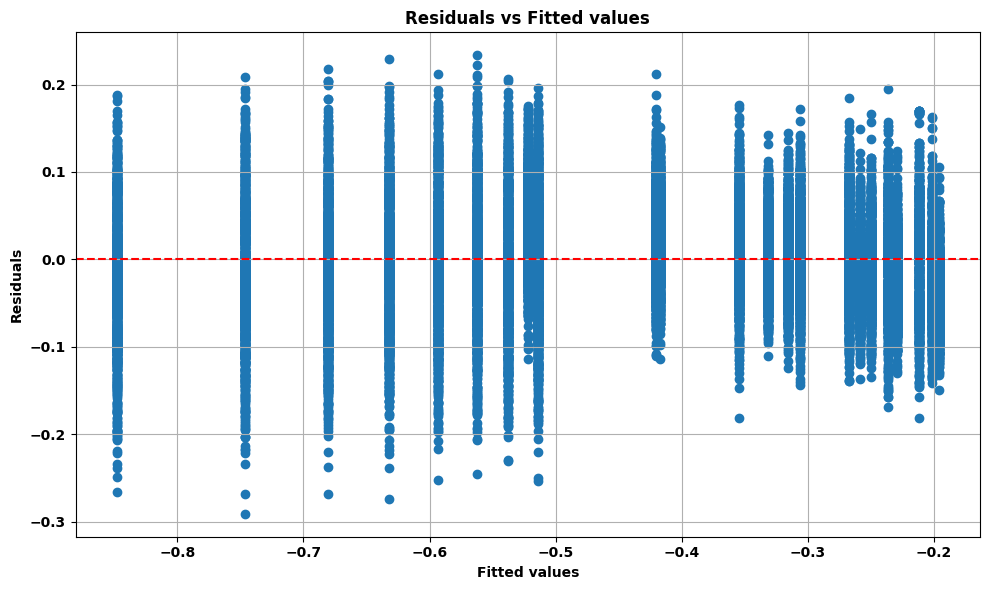

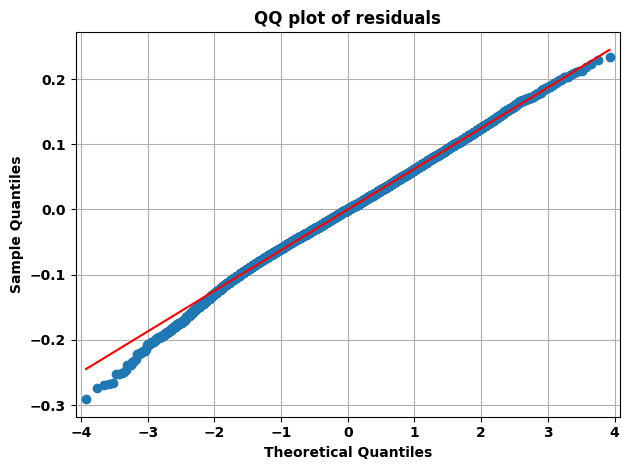

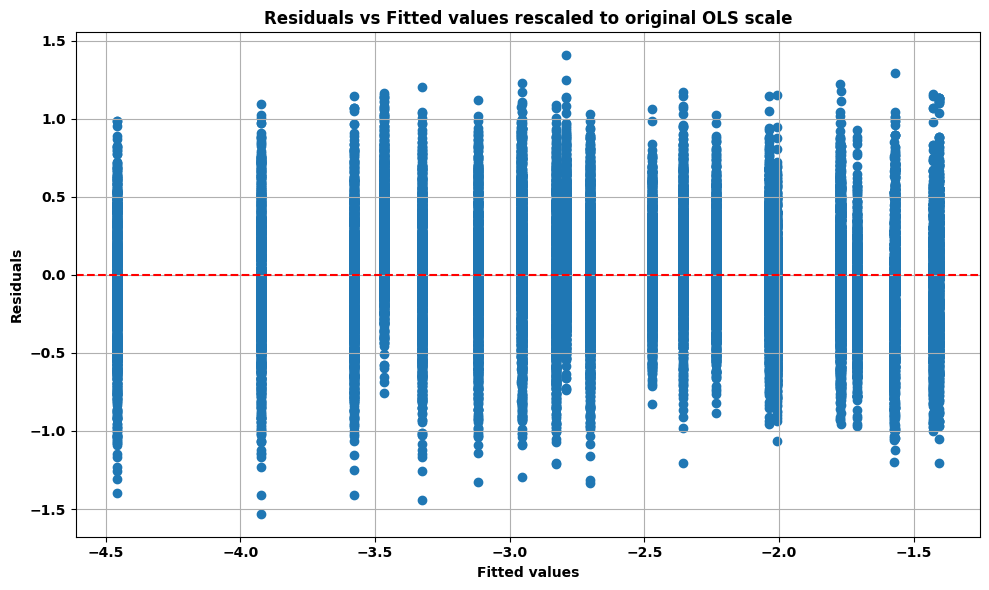

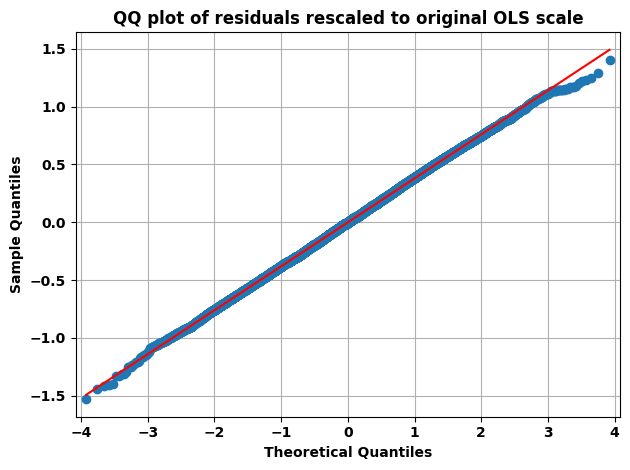

In [85]:
log_y = np.log(df_errors_ols['xT_error_inf_norm'])/np.log(df_errors_ols['M'])
log_x = np.log(df_errors_ols[f'log(M)/sqrt(N)'])
log_M = np.log(df_errors_ols['M'])

# Do OLS regression on log transformations

X = sm.add_constant(pd.DataFrame({
    # 'log(log(M))': np.log(np.log(df_errors_ols['M'])), 
    'log(M)': np.log(df_errors_ols['M']),
    'log(1/sqrt(N))': -np.log(np.sqrt(df_errors_ols['N']))
    }))
# X = sm.add_constant(np.array([log_x, log_M]).T)
Y = log_y
# Fit the model
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

from sklearn.metrics import r2_score
print(f"R2 (rescaled): {r2_score(np.log(df_errors_ols['M']) * log_y, np.log(df_errors_ols['M']) * results.predict(X))}")

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the QQ plot of the residuals
sm.qqplot(results.resid, line='s')
plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(np.log(df_errors_ols['M']) * results.fittedvalues, np.log(df_errors_ols['M']) * results.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values rescaled to original OLS scale')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the QQ plot of the residuals
sm.qqplot(np.log(df_errors_ols['M']) * results.resid, line='s')
plt.title('QQ plot of residuals rescaled to original OLS scale')
plt.grid(True)
plt.tight_layout()
plt.show()

In [86]:
c_log = results.params['const']
power_log = results.params['log(M)']
std_residuals_log = np.sqrt(results.mse_resid)
beta_log = results.params['log(1/sqrt(N))']
print(f"c={c_log}")
print(f"power={power_log}")
print(f"std_residuals={std_residuals_log}")
print(f"beta={beta_log}")

c=-0.7077742136492984
power=0.23520005516512252
std_residuals=0.062383227886882595
beta=0.18115674580021848


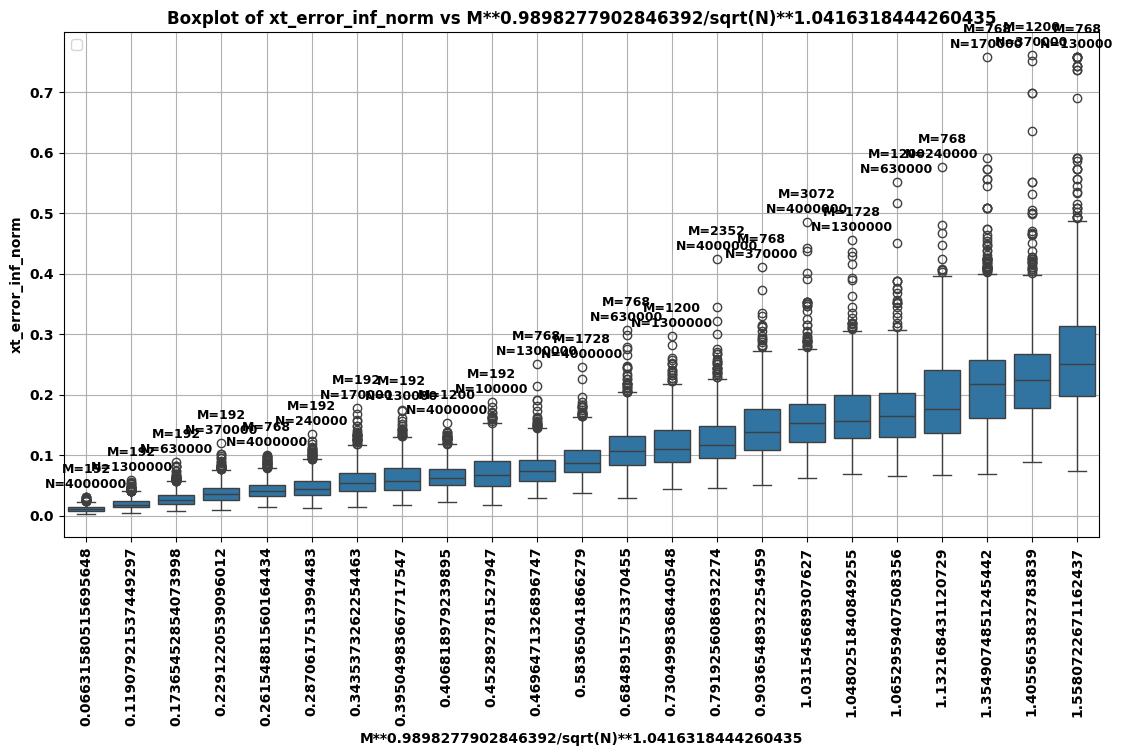

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

df_errors_ols[f'M**{power}/sqrt(N)**{beta}'] = df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']**beta

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x=f'M**{power}/sqrt(N)**{beta}', y='xT_error_inf_norm', data=df_errors_ols)

# Add a red dashed line for max_max_error
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')

# Set labels and title
plt.xlabel(f'M**{power}/sqrt(N)**{beta}')
plt.ylabel('xt_error_inf_norm')
plt.title(f'Boxplot of xt_error_inf_norm vs M**{power}/sqrt(N)**{beta}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)

# Annotate each box with M and N
grouped = df_errors_ols.groupby(f'M**{power}/sqrt(N)**{beta}')
for i, (name, group) in enumerate(grouped):
    # Use the first row as a representative for M and N
    M = group['M'].iloc[0]
    N = group['N'].iloc[0]
    ax.text(i, group['xT_error_inf_norm'].max() + 0.01, f'M={M}\nN={N}',
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.show()


# Illustrate how the distribution can be used to select number of states

In [92]:
number_of_data_points = 700_000 # Around one season
max_error_percentage = 10 # we want to be 90% sure that the error is reasonable

In [93]:
power=0.9898277902846392
beta=1.0416318444260435
std_residuals=0.36253906130541547
c=-1.8758112050799398

def cdf_max_xT_error(t, M, N):
    return norm.cdf(-c -power*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

def quartile_cdf_max_xT_error(M, N, quantile):
    return np.exp(norm.ppf(quantile, scale=std_residuals)) * np.exp(c) * M**power * np.sqrt(N)**(-beta)

In [94]:
nxs = np.arange(6, 32+1)
nys = np.ceil(nxs/4*3)

Ms = nxs * nys

q90 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.9)
q90

array([0.00638263, 0.00890515, 0.0101635 , 0.01330275, 0.01685138,
       0.02080843, 0.02268002, 0.02724858, 0.03222351, 0.03760412,
       0.04008474, 0.04607323, 0.05246589, 0.05926219, 0.06234872,
       0.06975011, 0.07755394, 0.08575979, 0.08944975, 0.09825842,
       0.10746812, 0.11707849, 0.12136982, 0.1315811 , 0.1421922 ,
       0.15320282, 0.15809378])

In [95]:
error_cdf = lambda t: norm.cdf(-c -power*np.log(M) + beta*np.log(np.sqrt(N)) + np.log(t), loc=0, scale=std_residuals)

In [96]:
nxs

array([ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
       23, 24, 25, 26, 27, 28, 29, 30, 31, 32])

In [97]:
nys

array([ 5.,  6.,  6.,  7.,  8.,  9.,  9., 10., 11., 12., 12., 13., 14.,
       15., 15., 16., 17., 18., 18., 19., 20., 21., 21., 22., 23., 24.,
       24.])

In [98]:
Ms

array([ 30.,  42.,  48.,  63.,  80.,  99., 108., 130., 154., 180., 192.,
       221., 252., 285., 300., 336., 374., 414., 432., 475., 520., 567.,
       588., 638., 690., 744., 768.])

Max M below max_max_error: 374.0
Corresponding nx: 22
Corresponding ny: 17.0


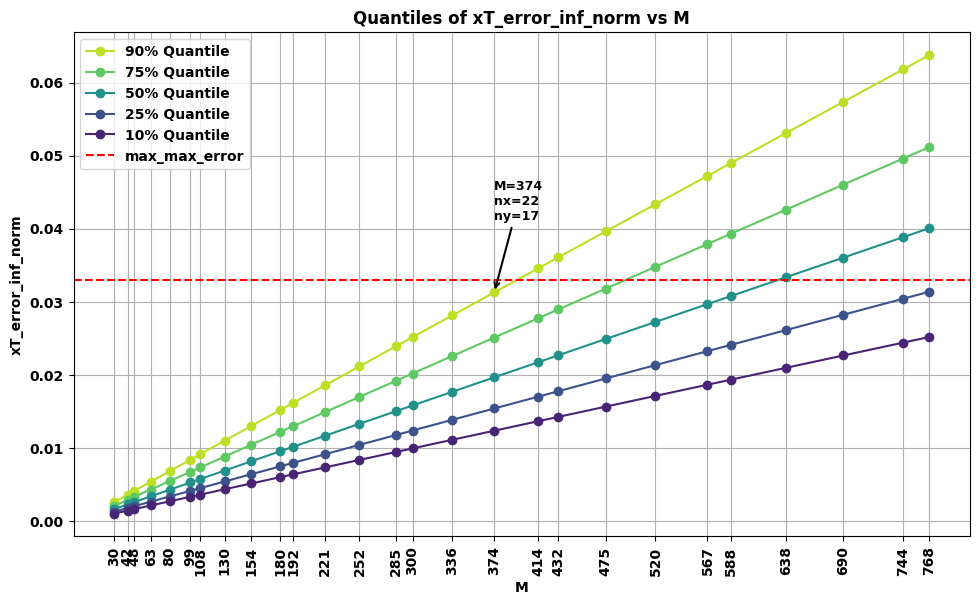

In [99]:
number_of_data_points = 4_000_000

cmap = matplotlib.colormaps['viridis']

# Plot the 90%, 50% and 10% quantiles for each value of M
plt.figure(figsize=(10, 6))
q90 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.9)
q75 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.75)
q50 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.5)
q25 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.25)
q10 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.1)
plt.plot(Ms, q90, label='90% Quantile', marker='o', color=cmap(0.9))
plt.plot(Ms, q75, label='75% Quantile', marker='o', color=cmap(0.75))
plt.plot(Ms, q50, label='50% Quantile', marker='o', color=cmap(0.5))
plt.plot(Ms, q25, label='25% Quantile', marker='o', color=cmap(0.25)) 
plt.plot(Ms, q10, label='10% Quantile', marker='o', color=cmap(0.1))

# Get the index of the largest M below max_max_error
index = np.argwhere(q90 < max_max_error)[-1][0]
# Get the corresponding M, nx, and ny values
M = Ms[index]
n_x = nxs[index]
n_y = nys[index]
print(f"Max M below max_max_error: {M}")
print(f"Corresponding nx: {n_x}")
print(f"Corresponding ny: {n_y}")

# Annotate the largest M below max_max_error
plt.annotate(f'M={int(M)}\nnx={int(n_x)}\nny={int(n_y)}', xy=(M, q90[index]), xytext=(M, q90[index]+0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('M')
plt.ylabel('xT_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
plt.xticks(Ms, rotation=90)
plt.show()


Max M below max_max_error: 180.0
Corresponding nx: 15
Corresponding ny: 12.0


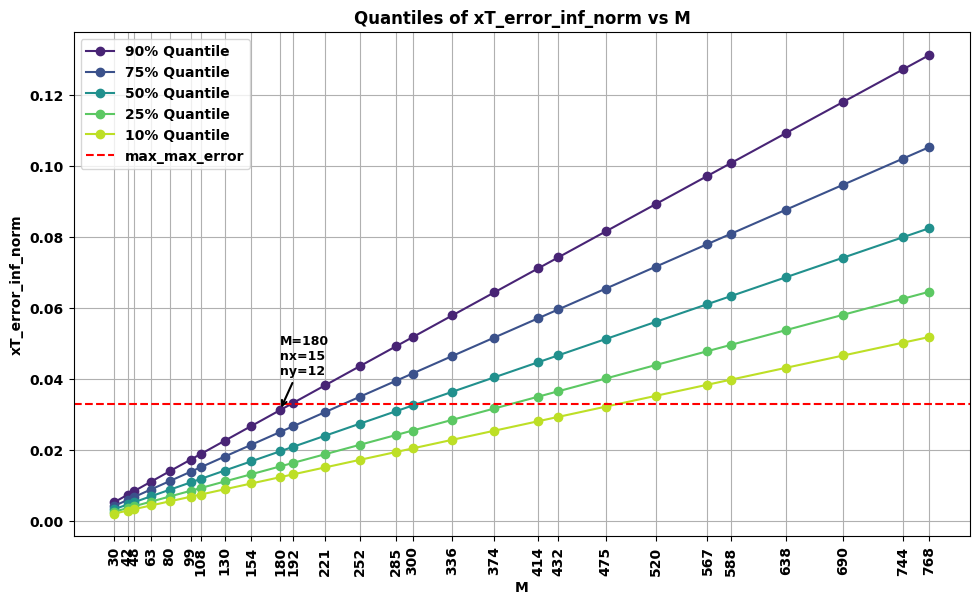

In [100]:
number_of_data_points = 1_000_000

cmap = matplotlib.colormaps['viridis_r']

# Plot the 90%, 50% and 10% quantiles for each value of M
plt.figure(figsize=(10, 6))
q90 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.9)
q75 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.75)
q50 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.5)
q25 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.25)
q10 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.1)
plt.plot(Ms, q90, label='90% Quantile', marker='o', color=cmap(0.9))
plt.plot(Ms, q75, label='75% Quantile', marker='o', color=cmap(0.75))
plt.plot(Ms, q50, label='50% Quantile', marker='o', color=cmap(0.5))
plt.plot(Ms, q25, label='25% Quantile', marker='o', color=cmap(0.25)) 
plt.plot(Ms, q10, label='10% Quantile', marker='o', color=cmap(0.1))

# Get the index of the largest M below max_max_error
index = np.argwhere(q90 < max_max_error)[-1][0]
# Get the corresponding M, nx, and ny values
M = Ms[index]
n_x = nxs[index]
n_y = nys[index]
print(f"Max M below max_max_error: {M}")
print(f"Corresponding nx: {n_x}")
print(f"Corresponding ny: {n_y}")

# Annotate the largest M below max_max_error
plt.annotate(f'M={int(M)}\nnx={int(n_x)}\nny={int(n_y)}', xy=(M, q90[index]), xytext=(M, q90[index]+0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('M')
plt.ylabel('xT_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
plt.xticks(Ms, rotation=90)
plt.show()


Min N below max_max_error: 4700000.0


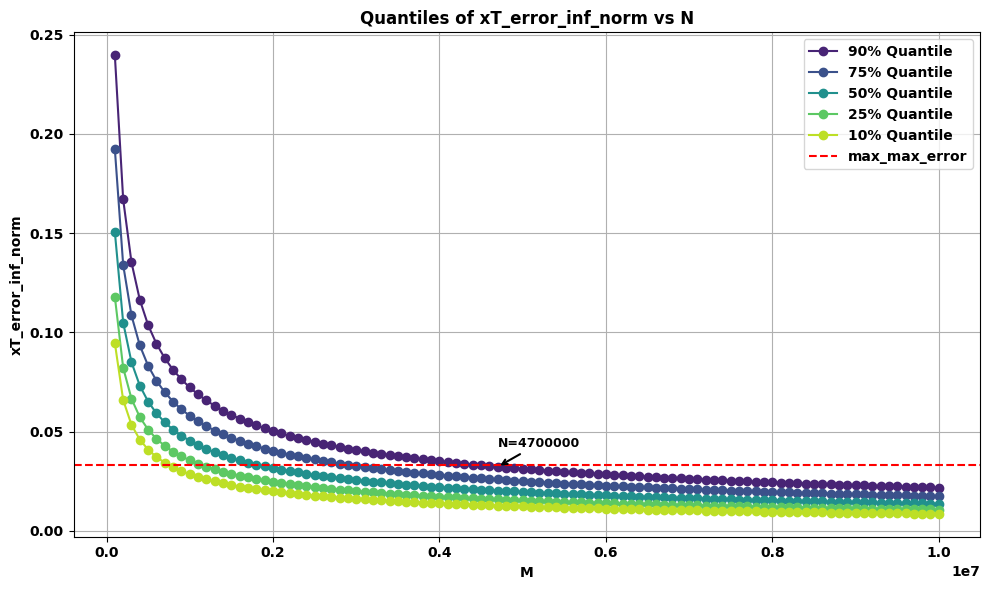

In [104]:
desired_markov_states = 420

Ns = np.linspace(100_000, 10_000_000, 100)

cmap = matplotlib.colormaps['viridis_r']

# Plot the 90%, 50% and 10% quantiles for each value of M
plt.figure(figsize=(10, 6))
q90 = quartile_cdf_max_xT_error(desired_markov_states, Ns, 0.9)
q75 = quartile_cdf_max_xT_error(desired_markov_states, Ns, 0.75)
q50 = quartile_cdf_max_xT_error(desired_markov_states, Ns, 0.5)
q25 = quartile_cdf_max_xT_error(desired_markov_states, Ns, 0.25)
q10 = quartile_cdf_max_xT_error(desired_markov_states, Ns, 0.1)
plt.plot(Ns, q90, label='90% Quantile', marker='o', color=cmap(0.9))
plt.plot(Ns, q75, label='75% Quantile', marker='o', color=cmap(0.75))
plt.plot(Ns, q50, label='50% Quantile', marker='o', color=cmap(0.5))
plt.plot(Ns, q25, label='25% Quantile', marker='o', color=cmap(0.25)) 
plt.plot(Ns, q10, label='10% Quantile', marker='o', color=cmap(0.1))

# Get the index of the largest M below max_max_error
index = np.argwhere(q90 < max_max_error)[1][0]
# Get the corresponding M, nx, and ny values
N = Ns[index]

print(f"Min N below max_max_error: {N}")


# Annotate the smalles N below max_max_error
plt.annotate(f'N={int(N)}', xy=(N, q90[index]), xytext=(N, q90[index]+0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('M')
plt.ylabel('xT_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs N')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
# plt.xticks(Ns, rotation=90)
plt.show()


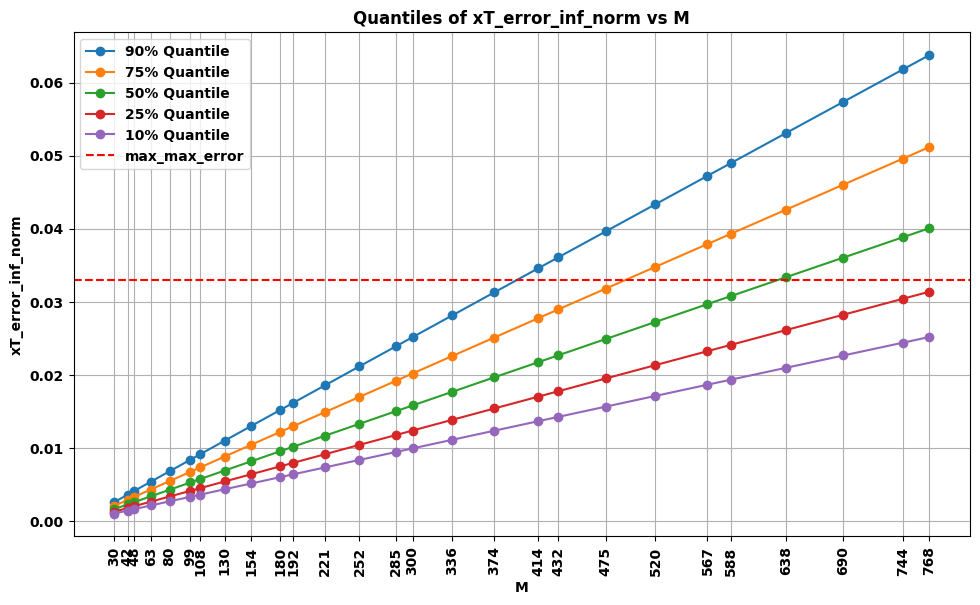

In [96]:
number_of_data_points = 4_000_000

# Plot the 90%, 50% and 10% quantiles for each value of M
plt.figure(figsize=(10, 6))
q90 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.9)
q75 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.75)
q50 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.5)
q25 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.25)
q10 = quartile_cdf_max_xT_error(Ms, number_of_data_points, 0.1)
plt.plot(Ms, q90, label='90% Quantile', marker='o')
plt.plot(Ms, q75, label='75% Quantile', marker='o')
plt.plot(Ms, q50, label='50% Quantile', marker='o')
plt.plot(Ms, q25, label='25% Quantile', marker='o') 
plt.plot(Ms, q10, label='10% Quantile', marker='o')

# Add horizontal line at max_max_error
plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('M')
plt.ylabel('xT_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
plt.xticks(Ms, rotation=90)
plt.show()


In [55]:
# Plot the 90%, 50% and 10% quantiles for each value of M
plt.figure(figsize=(10, 6))
for i, M in enumerate(Ms):
    # Calculate the quantiles
    q90 = quartile_cdf_max_xT_error(M, number_of_data_points, 0.9)
    q50 = quartile_cdf_max_xT_error(M, number_of_data_points, 0.5)
    q10 = quartile_cdf_max_xT_error(M, number_of_data_points, 0.1)

    # Plot the quantiles
    plt.plot([i]*3, [q90, q50, q10], marker='o', label=f'M={M}')
    plt.axhline(y=q90, color='red', linestyle='--', label='90% Quantile')
    plt.axhline(y=q50, color='blue', linestyle='--', label='50% Quantile')
    plt.axhline(y=q10, color='green', linestyle='--', label='10% Quantile')
    plt.text(i, q90 + 0.01, f'{q90:.2f}', ha='center', va='bottom', fontsize=9)
    plt.text(i, q50 + 0.01, f'{q50:.2f}', ha='center', va='bottom', fontsize=9)
    plt.text(i, q10 + 0.01, f'{q10:.2f}', ha='center', va='bottom', fontsize=9)
plt.xlabel('M')
plt.ylabel('Quantiles of xT_error_inf_norm')
plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(range(len(Ms)), [f'M={M}' for M in Ms])
plt.show()



TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. matplotlib.backends._backend_agg.RendererAgg(width: int, height: int, dpi: float)

Invoked with: 870, 22764365731864, 100.0

<Figure size 1000x600 with 1 Axes>